In [1]:
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

In [2]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x

In [3]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [4]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from numpy import loadtxt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
import pylab as pl

from collections import Counter
from sklearn.datasets import make_classification

In [5]:
# Función para comprimir datos #######################################################
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [6]:
import numpy as np

In [7]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

# MODELOS

In [8]:
from sagemaker.tuner import HyperparameterTuner
#Solo variables importantes
nombre_exportado = HyperparameterTuner.attach('hpo-plaft-pj-minoris-260730-1333').best_training_job()
print(nombre_exportado)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/estimator.py:588: SageMakerV2DeprecationWarning: Estimator is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://g

hpo-plaft-pj-minoris-260730-1333-032-3477f357


In [9]:
#!pip install xgboost --prefer-binary

In [10]:
!pip install --force-reinstall "xgboost==1.7.6"

  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 124.7 MB/s  0:00:010:00:0100:01
Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
  Attempting uninstall: scipy━━━━━━━━━━━━━━━━━━━ 0/3 [numpy]
    Found existing installation: scipy 1.15.3 0/3 [numpy]
    Uninstalling scipy-1.15.3:━━━━━━━━━━━━━━ 0/3 [numpy]
      Successfully uninstalled scipy-1.15.3━ 0/3 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [xgboost]m2/3 [xgboost]


In [11]:
import xgboost as xgb

print(xgb.__version__)

1.7.6


In [14]:
import boto3
import tarfile
import xgboost as xgb
import os

# Parámetros
# Parámetros
bucket_name = 'ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'
nombre_exportado = 'hpo-plaft-pj-minoris-260730-1333-032-3477f357'

# Descargar model.tar.gz desde S3
s3 = boto3.client('s3')

with open('model.tar.gz', 'wb') as f:
    s3.download_fileobj(
        bucket_name,
        f'{model_prefix}/MODEL/output/{nombre_exportado}/output/model.tar.gz',
        f
    )

# Extraer el archivo tar.gz
with tarfile.open('model.tar.gz', 'r:gz') as tar:
    tar.extractall(path='model')

# Cargar el modelo con XGBoost
model_path = os.path.join('model', 'xgboost-model')
model = xgb.Booster()
model.load_model(model_path)

# ¡Listo! Ya podés usar model.predict(...) con DMatrix


In [15]:
import pandas as pd

import pandas as pd

# ===============================================================
# 1. Parámetros de tu bucket y prefijo
# ===============================================================
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

# Ejemplo completo:
# bucket_name  = "sagemaker-us-east-1-123456789012"
# model_prefix = "risk-fraud-model/2025-12-05"

# ===============================================================
# 2. Rutas en S3
# ===============================================================
base_s3_path = f"s3://{bucket_name}/{model_prefix}/data_dev_model"

headers_path      = f"{base_s3_path}/headers_total.csv"
train_path        = f"{base_s3_path}/train_total.csv"
val_path          = f"{base_s3_path}/validation_total.csv"
test_path         = f"{base_s3_path}/test_total.csv"
extras_val_path   = f"{base_s3_path}/extras_validation_total.csv"
extras_test_path  = f"{base_s3_path}/extras_test_total.csv"

# ===============================================================
# 3. Cargar headers (orden y tipos)
# ===============================================================
headers = pd.read_csv(headers_path)
column_order = headers['variables'].tolist()

print(f"Se cargaron {len(column_order)} variables desde S3")
print("Primeras 10 variables:", column_order[:10])

# ===============================================================
# 4. Cargar train / val / test SIN header, pero CON nombres correctos
# ===============================================================
df_train = pd.read_csv(train_path, header=None, names=column_order)
df_val   = pd.read_csv(val_path,   header=None, names=column_order)
df_test  = pd.read_csv(test_path,  header=None, names=column_order)

print(f"\nShapes cargados desde S3:")
print(f"  Train : {df_train.shape}")
print(f"  Val   : {df_val.shape}")
print(f"  Test  : {df_test.shape}")

# ===============================================================
# 5. Cargar extras (num_documento, mes_base, tipo_alerta_n2)
# ===============================================================
extras_val  = pd.read_csv(extras_val_path)
extras_test = pd.read_csv(extras_test_path)

# Pegamos las columnas de reporting al dataframe original
df_val  = pd.concat([df_val.reset_index(drop=True), 
                     extras_val[['key_value','cod_cli' ,'cod_mes','tipo_alerta_n2','trx_riesgo_cliente']]], axis=1)

df_test = pd.concat([df_test.reset_index(drop=True), 
                     extras_test[['key_value','cod_cli' , 'cod_mes','tipo_alerta_n2','trx_riesgo_cliente']]], axis=1)

# ===============================================================
# 6. Verificación final
# ===============================================================
print("\nListo! Todo cargado correctamente desde S3")
print(f"df_val  ahora tiene {df_val.shape[1]} columnas (incluye num_documento y mes_base)")
print(f"df_test ahora tiene {df_test.shape[1]} columnas")

# Ejemplo rápido de uso
display(df_val[['key_value', 'cod_cli' ,'cod_mes', 'target','tipo_alerta_n2','trx_riesgo_cliente']].head())

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:305: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Se cargaron 33 variables desde S3
Primeras 10 variables: ['target', 'cnt_trx_cargostot_3m', 'rat_pastot_x_ingtot_6m', 'imp_trx_abonosefect_6m', 'mto_pas_soles', 'imp_trx_cargosefe_6m', 'cnt_alerta_hist', 'cnt_meses_sinegresos_12m', 'mto_del_ext_12m', 'num_antiguedad']

Shapes cargados desde S3:
  Train : (175400, 33)
  Val   : (324253, 33)
  Test  : (1509824, 33)

Listo! Todo cargado correctamente desde S3
df_val  ahora tiene 38 columnas (incluye num_documento y mes_base)
df_test ahora tiene 38 columnas


,key_value,cod_cli,cod_mes,target,tipo_alerta_n2,trx_riesgo_cliente
0,CFBB0B2F5FD6513C86D87E443AE6AB77E602A9E2838E92...,19624888.0,202508.0,0.0,SIN_INFO,SIN_INFO
1,5EDCFFE54DFF78B5822DC3A6D788AB6492503FEB107E61...,21415266.0,202508.0,0.0,SIN_INFO,SIN_INFO
2,726792FA75C0F81CE4B29414E4E356015115AA8A1314F8...,20771814.0,202508.0,0.0,SIN_INFO,SIN_INFO
3,68EC68DE2DCD2863EE9358C1A5114AF696EC427C61A188...,15796105.0,202508.0,0.0,SIN_INFO,SIN_INFO
4,1FD783E55834088187103E67D52C290BEC026560D60D77...,19084916.0,202508.0,0.0,SIN_INFO,SIN_INFO


In [16]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [17]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 !='SIN_INFO')]

In [18]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_test_3 = df_test.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cod_cli', 'cod_mes', 'tipo_alerta_n2','trx_riesgo_cliente']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [19]:
df_test_3['prob'] = model.predict(dtest)

In [20]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_test_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202508.0    0.939744
202509.0    0.920905
202510.0    0.864290
202511.0    0.905303
202512.0    0.910615
202601.0    0.940020
202602.0    0.924500
202603.0    0.911931
202604.0    0.955900
dtype: float64


/tmp/ipykernel_14266/29427415.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_test_3.groupby('cod_mes').apply(


In [21]:
gini_promedio = gini_por_mes.mean()

print(f"\nGini promedio de todos los meses: {gini_promedio:.4f}")



Gini promedio de todos los meses: 0.9192


In [23]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# -------------------------------------------------
# Configuración
# -------------------------------------------------
MES = 202508
THRESHOLD = 0.99296  # tu umbral definido
cols_excluir = ['key_value', 'cod_cli' ,'cod_mes', 'cod_cli' , 'tipo_alerta_n2', 'target','trx_riesgo_cliente']

# -------------------------------------------------
# Filtrar datos del mes
# -------------------------------------------------
test_data = df_test[df_test.cod_mes == float(MES)].copy()

if test_data.empty:
    print(f"⚠️ No hay datos para el mes {MES}")
else:
    # Preparar X_test
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    # Predicciones
    test_data['prob'] = model.predict(dtest)

    # Verdaderos / predichos
    y_true = test_data['target'].values
    y_score = test_data['prob'].values
    y_pred = (y_score >= THRESHOLD).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n=== Matriz de Confusión Mes {MES} ===")
    print(pd.DataFrame(
        cm,
        index=["Real 0", "Real 1"],
        columns=["Pred 0", "Pred 1"]
    ))
    print(f"\nTP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")
    print(f"Precision: {tp / (tp + fp):.4f}")
    print(f"Recall:    {tp / (tp + fn):.4f}")



=== Matriz de Confusión Mes 202508 ===
        Pred 0  Pred 1
Real 0  161071     225
Real 1      90      29

TP: 29 | FP: 225 | FN: 90 | TN: 161071
Precision: 0.1142
Recall:    0.2437


In [ ]:
#validation

In [49]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_val_3 = df_val.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cod_cli', 'cod_mes', 'tipo_alerta_n2','trx_riesgo_cliente']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_val_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [50]:
df_val_3['prob'] = model.predict(dtest)

In [51]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_val_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)

Gini por mes:
cod_mes
202508.0    0.939744
202509.0    0.920905
dtype: float64


/tmp/ipykernel_14266/1839909994.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_val_3.groupby('cod_mes').apply(


In [48]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [49]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')]

In [25]:
meses = [202508, 202509, 202510, 202511, 202512,202601,202602,202603,202604]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_cli' ,'cod_mes',  'cod_cli' ,'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=5
    )

In [26]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.010100000000000001, 0.093]",32285,1,0.000031,0.200160,1.000000,32285,119
"(0.093, 0.134]",32590,0,0.000000,0.402211,0.991597,64875,118
"(0.134, 0.189]",31972,1,0.000031,0.600430,0.991597,96847,118
"(0.189, 0.302]",32282,1,0.000031,0.800572,0.983193,129129,117
"(0.302, 0.999]",32167,116,0.003593,1.000000,0.974790,161296,116


In [27]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00807, 0.093]",32568,0,0.000000,0.200124,1.000000,32568,99
"(0.093, 0.134]",33043,1,0.000030,0.403167,1.000000,65611,99
"(0.134, 0.188]",32091,0,0.000000,0.600360,0.989899,97702,98
"(0.188, 0.302]",32563,4,0.000123,0.800453,0.989899,130265,98
"(0.302, 0.998]",32474,94,0.002886,1.000000,0.949495,162739,94


In [28]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.009899999999999999, 0.0935]",32954,1,0.000030,0.200145,1.000000,32954,123
"(0.0935, 0.134]",32953,2,0.000061,0.400283,0.991870,65907,122
"(0.134, 0.189]",32956,3,0.000091,0.600440,0.975610,98863,120
"(0.189, 0.306]",32944,6,0.000182,0.800524,0.951220,131807,117
"(0.306, 0.998]",32844,111,0.003368,1.000000,0.902439,164651,111


In [29]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.010100000000000001, 0.0943]",33265,0,0.000000,0.200088,1.000000,33265,65
"(0.0943, 0.136]",33263,0,0.000000,0.400164,1.000000,66528,65
"(0.136, 0.191]",33261,2,0.000060,0.600227,1.000000,99789,65
"(0.191, 0.311]",33261,1,0.000030,0.800291,0.969231,133050,63
"(0.311, 0.998]",33202,62,0.001864,1.000000,0.953846,166252,62


In [30]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00748, 0.0921]",34267,0,0.000000,0.200023,1.0000,34267,16
"(0.0921, 0.134]",34309,0,0.000000,0.400292,1.0000,68576,16
"(0.134, 0.19]",34222,1,0.000029,0.600053,1.0000,102798,16
"(0.19, 0.309]",34266,0,0.000000,0.800070,0.9375,137064,15
"(0.309, 0.999]",34251,15,0.000438,1.000000,0.9375,171315,15


In [31]:
tablas_quintiles[202603]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0103, 0.0924]",34085,1,0.000029,0.200147,1.000000,34085,126
"(0.0924, 0.135]",34106,1,0.000029,0.400417,0.992063,68191,125
"(0.135, 0.193]",34063,0,0.000000,0.600435,0.984127,102254,124
"(0.193, 0.313]",34081,4,0.000117,0.800558,0.984127,136335,124
"(0.313, 0.999]",33965,120,0.003521,1.000000,0.952381,170300,120


In [32]:
tablas_quintiles[202604]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0121, 0.0911]",34500,1,0.000029,0.200266,1.000000,34500,234
"(0.0911, 0.134]",34500,1,0.000029,0.400532,0.995726,69000,233
"(0.134, 0.192]",34501,0,0.000000,0.600803,0.991453,103501,232
"(0.192, 0.314]",34611,0,0.000000,0.801714,0.991453,138112,232
"(0.314, 0.999]",34159,232,0.006746,1.000000,0.991453,172271,232


In [48]:
df_test_2= df_test[(df_test.cod_mes ==202604)]

In [34]:
#solo alarmas 

In [35]:
df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [36]:
meses = [202508, 202509, 202510, 202511, 202512,202601,202602,202603,202604]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test_1[df_test_1.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_cli' ,'cod_mes',  'cod_cli' ,'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=5
    )

In [37]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.118, 0.625]",36,3,0.076923,0.227848,1.000000,36,34
"(0.625, 0.788]",34,4,0.105263,0.443038,0.911765,70,31
"(0.788, 0.889]",34,4,0.105263,0.658228,0.794118,104,27
"(0.889, 0.974]",31,7,0.184211,0.854430,0.676471,135,23
"(0.974, 0.999]",23,16,0.410256,1.000000,0.470588,158,16


In [38]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.17099999999999999, 0.704]",54,1,0.018182,0.212598,1.000000,54,17
"(0.704, 0.827]",52,2,0.037037,0.417323,0.941176,106,16
"(0.827, 0.92]",54,0,0.000000,0.629921,0.823529,160,14
"(0.92, 0.976]",52,2,0.037037,0.834646,0.823529,212,14
"(0.976, 0.997]",42,12,0.222222,1.000000,0.705882,254,12


In [39]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0528, 0.557]",55,0,0.000000,0.226337,1.000000,55,29
"(0.557, 0.803]",52,2,0.037037,0.440329,1.000000,107,29
"(0.803, 0.915]",49,5,0.092593,0.641975,0.931034,156,27
"(0.915, 0.981]",50,4,0.074074,0.847737,0.758621,206,22
"(0.981, 0.998]",37,18,0.327273,1.000000,0.620690,243,18


In [40]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.133, 0.704]",33,3,0.083333,0.207547,1.000000,33,19
"(0.704, 0.812]",33,2,0.057143,0.415094,0.842105,66,16
"(0.812, 0.912]",36,0,0.000000,0.641509,0.736842,102,14
"(0.912, 0.979]",29,6,0.171429,0.823899,0.736842,131,14
"(0.979, 0.997]",28,8,0.222222,1.000000,0.421053,159,8


In [41]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.155, 0.594]",56,0,0.000000,0.203636,1.0,56,2
"(0.594, 0.777]",55,0,0.000000,0.403636,1.0,111,2
"(0.777, 0.858]",55,0,0.000000,0.603636,1.0,166,2
"(0.858, 0.924]",54,1,0.018182,0.800000,1.0,220,2
"(0.924, 0.996]",55,1,0.017857,1.000000,0.5,275,1


In [42]:
tablas_quintiles[202601]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.21, 0.719]",25,2,0.074074,0.240385,1.000000,25,27
"(0.719, 0.844]",22,4,0.153846,0.451923,0.925926,47,25
"(0.844, 0.954]",21,5,0.192308,0.653846,0.777778,68,21
"(0.954, 0.989]",18,8,0.307692,0.826923,0.592593,86,16
"(0.989, 0.997]",18,8,0.307692,1.000000,0.296296,104,8


In [43]:
tablas_quintiles[202602]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.061799999999999994, 0.609]",105,0,0.000000,0.204280,1.000000,105,11
"(0.609, 0.793]",105,0,0.000000,0.408560,1.000000,210,11
"(0.793, 0.885]",104,1,0.009524,0.610895,1.000000,314,11
"(0.885, 0.956]",102,3,0.028571,0.809339,0.909091,416,10
"(0.956, 0.998]",98,7,0.066667,1.000000,0.636364,514,7


In [44]:
tablas_quintiles[202603]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.13999999999999999, 0.497]",25,0,0.000000,0.217391,1.000,25,8
"(0.497, 0.782]",23,1,0.041667,0.417391,1.000,48,8
"(0.782, 0.891]",23,2,0.080000,0.617391,0.875,71,7
"(0.891, 0.981]",20,4,0.166667,0.791304,0.625,91,5
"(0.981, 0.997]",24,1,0.040000,1.000000,0.125,115,1


In [45]:
tablas_quintiles[202604]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.226, 0.836]",52,9,0.147541,0.270833,1.000000,52,111
"(0.836, 0.915]",45,15,0.250000,0.505208,0.918919,97,102
"(0.915, 0.968]",42,19,0.311475,0.723958,0.783784,139,87
"(0.968, 0.987]",26,34,0.566667,0.859375,0.612613,165,68
"(0.987, 0.999]",27,34,0.557377,1.000000,0.306306,192,34


In [65]:
#from pathlib import Path
#output_path = Path(r"/PLAFT/Desarrollo/Desarrollo/PJ/MINORISTA/Artefactos/Inferencia/alertas_ordenadas_automaticas_sinriegoalto.csv")
#df_test_2.to_csv(output_path, index=False, encoding="utf-8-sig")
#print(f"✓ CSV exportado: {output_path} | Filas: {len(df_test_2):,}")

In [54]:
meses = [202508, 202509, 202510, 202511,202512]
tablas_quintiles = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    # Predicción (asumiendo que ya tienes `predictions`)
    cols_excluir = ['key_value', 'cod_mes', 'cod_cli' , 'tipo_alerta_n2','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')
    X_test = X_test.drop(columns=['target'], errors='ignore')
    dtest = xgb.DMatrix(X_test, enable_categorical=True)

    test_data['prob'] = model.predict(dtest)

    # Filtro indicado
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    # Tabla QUINTILES
    tablas_quintiles[mes] = Tabla_Deciles(
        test_data_alerta['target'],
        test_data_alerta['prob'],
        n=1000
    )


In [55]:
tablas_quintiles[202508]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0111, 0.022805]",171,0,0.000000,0.001060,1.000000,171,119
"(0.022805, 0.024861]",152,0,0.000000,0.002003,1.000000,323,119
"(0.024861, 0.025213]",233,0,0.000000,0.003447,1.000000,556,119
"(0.025213, 0.025464]",220,0,0.000000,0.004811,1.000000,776,119
"(0.025464, 0.025728]",113,0,0.000000,0.005512,1.000000,889,119
...,...,...,...,...,...,...,...
"(0.98326, 0.9867]",156,6,0.037037,0.996293,0.453782,160698,54
"(0.9867, 0.98947]",151,10,0.062112,0.997229,0.403361,160849,48
"(0.98947, 0.99176]",158,4,0.024691,0.998208,0.319328,161007,38


In [56]:
tablas_quintiles[202509]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.009065350000000002, 0.0228584]",163,0,0.000000,0.001002,1.000000,163,99
"(0.0228584, 0.0249248]",166,0,0.000000,0.002022,1.000000,329,99
"(0.0249248, 0.0252133]",211,0,0.000000,0.003318,1.000000,540,99
"(0.0252133, 0.0254645]",220,0,0.000000,0.004670,1.000000,760,99
"(0.0254645, 0.0257275]",113,0,0.000000,0.005364,1.000000,873,99
...,...,...,...,...,...,...,...
"(0.983604, 0.986984]",158,4,0.024691,0.996166,0.323232,162115,32
"(0.986984, 0.989744]",157,6,0.036810,0.997130,0.282828,162272,28
"(0.989744, 0.992086]",156,7,0.042945,0.998089,0.222222,162428,22


In [57]:
tablas_quintiles[202510]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0109054, 0.0228854]",165,0,0.000000,0.001002,1.000000,165,123
"(0.0228854, 0.0249262]",165,0,0.000000,0.002004,1.000000,330,123
"(0.0249262, 0.0252133]",214,0,0.000000,0.003304,1.000000,544,123
"(0.0252133, 0.0254645]",218,0,0.000000,0.004628,1.000000,762,123
"(0.0254645, 0.0257275]",117,0,0.000000,0.005339,1.000000,879,123
...,...,...,...,...,...,...,...
"(0.983896, 0.987386]",159,5,0.030488,0.996241,0.373984,164032,46
"(0.987386, 0.990005]",162,3,0.018182,0.997224,0.333333,164194,41
"(0.990005, 0.992466]",160,5,0.030303,0.998196,0.308943,164354,38


In [58]:
tablas_quintiles[202511]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0111088, 0.0228207]",167,0,0.000000,0.001004,1.000000,167,65
"(0.0228207, 0.02494]",177,0,0.000000,0.002069,1.000000,344,65
"(0.02494, 0.0252133]",200,0,0.000000,0.003272,1.000000,544,65
"(0.0252133, 0.0254645]",220,0,0.000000,0.004595,1.000000,764,65
"(0.0254645, 0.0257275]",118,0,0.000000,0.005305,1.000000,882,65
...,...,...,...,...,...,...,...
"(0.985186, 0.988008]",165,1,0.006024,0.996096,0.276923,165603,18
"(0.988008, 0.990402]",163,4,0.023952,0.997077,0.261538,165766,17
"(0.990402, 0.992792]",165,1,0.006024,0.998069,0.200000,165931,13


In [59]:
tablas_quintiles[202512]

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00848311, 0.0228931]",180,0,0.000000,0.001051,1.000,180,16
"(0.0228931, 0.02494]",174,0,0.000000,0.002066,1.000,354,16
"(0.02494, 0.0252133]",204,0,0.000000,0.003257,1.000,558,16
"(0.0252133, 0.0254645]",221,0,0.000000,0.004547,1.000,779,16
"(0.0254645, 0.0257275]",122,0,0.000000,0.005259,1.000,901,16
...,...,...,...,...,...,...,...
"(0.985278, 0.988533]",171,0,0.000000,0.996019,0.250,170633,4
"(0.988533, 0.990613]",172,0,0.000000,0.997023,0.250,170805,4
"(0.990613, 0.99296]",169,2,0.011696,0.998010,0.250,170974,4


In [60]:
import pandas as pd
import numpy as np

def metricas_top_k(df, target_col, score_col, k_list):
    """
    Calcula Recall@K y Precision@K para distintos valores de K
    """
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    total_positivos = df[target_col].sum()

    resultados = []

    for k in k_list:
        top_k = df.head(k)
        tp_k = top_k[target_col].sum()

        recall_k = tp_k / total_positivos if total_positivos > 0 else 0
        precision_k = tp_k / k if k > 0 else 0

        resultados.append({
            "K": k,
            "score_min": top_k[score_col].min(),
            "TP": tp_k,
            "Recall": recall_k,
            "Precision": precision_k
        })

    return pd.DataFrame(resultados)


In [61]:
meses = [202508, 202509, 202510, 202511, 202512,202604]
k_list = [100, 200, 500, 1000, 2000]

resultados_meses = {}

for mes in meses:

    test_data = df_test[df_test.cod_mes == float(mes)].copy()

    cols_excluir = ['key_value', 'cod_mes',  'cod_cli' ,'tipo_alerta_n2', 'target','trx_riesgo_cliente']
    X_test = test_data.drop(columns=cols_excluir, errors='ignore')

    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    test_data['prob'] = model.predict(dtest)

    # Solo alertas nuevas
    test_data_alerta = test_data[
        test_data.tipo_alerta_n2 != 0
    ].copy()

    if test_data_alerta.empty:
        continue

    tabla_k = metricas_top_k(
        test_data_alerta,
        target_col="target",
        score_col="prob",
        k_list=k_list
    )

    tabla_k["mes"] = mes
    resultados_meses[mes] = tabla_k


In [62]:
df_metricas = pd.concat(
    resultados_meses.values(),
    ignore_index=True
)

df_metricas


,K,score_min,TP,Recall,Precision,mes
0,100,0.995062,21.0,0.176471,0.2100,202508
1,200,0.993688,28.0,0.235294,0.1400,202508
2,500,0.989254,39.0,0.327731,0.0780,202508
3,1000,0.977952,56.0,0.470588,0.0560,202508
4,2000,0.946873,76.0,0.638655,0.0380,202508
5,100,0.995354,9.0,0.090909,0.0900,202509
6,200,0.993621,9.0,0.090909,0.0450,202509
7,500,0.989555,23.0,0.232323,0.0460,202509
8,1000,0.978834,37.0,0.373737,0.0370,202509
9,2000,0.948134,52.0,0.525253,0.0260,202509


In [63]:
def optimal_threshold_topk(
    df,
    score_col="prob",
    target_col="target",
    k=1000,
    n_groups=5
):
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # Total positivos reales (para recall)
    total_positivos = (df[target_col] == 1).sum()

    # Nos quedamos solo con los top K
    df_topk = df.iloc[:k].copy()

    group_size = k // n_groups
    resultados = []

    acumulado = pd.DataFrame()

    for g in range(1, n_groups + 1):
        inicio = (g - 1) * group_size
        fin = g * group_size

        acumulado = df_topk.iloc[:fin]

        tp = (acumulado[target_col] == 1).sum()
        fp = fin - tp
        fn = total_positivos - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0
        )

        threshold = acumulado[score_col].min()

        resultados.append({
            "grupo": g,
            "casos_hasta": fin,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(resultados)


In [64]:
resultados_mes = {}

for mes in meses:
    df_mes = df_test[df_test.cod_mes == mes].copy()
    df_mes = df_mes[df_mes.tipo_alerta_n2 != 0]

    if df_mes.empty:
        continue

    X = df_mes.drop(
        columns=["key_value", "cod_mes", 'cod_cli' , "tipo_alerta_n2", "target","trx_riesgo_cliente"],
        errors="ignore"
    )

    dtest = xgb.DMatrix(X)
    df_mes["prob"] = model.predict(dtest)

    tabla = optimal_threshold_topk(
        df_mes,
        score_col="prob",
        target_col="target",
        k=1000,
        n_groups=5
    )

    resultados_mes[mes] = tabla



In [65]:
for mes, tabla in resultados_mes.items():
    print(f"\nMes {mes}")
    display(tabla.sort_values("f1", ascending=False).head(1))



Mes 202508


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.993688,0.14,0.235294,0.175549



Mes 202509


,grupo,casos_hasta,threshold,precision,recall,f1
2,3,600,0.988034,0.043333,0.262626,0.074392



Mes 202510


...

,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.994506,0.05,0.153846,0.075472



Mes 202512


,grupo,casos_hasta,threshold,precision,recall,f1
2,3,600,0.989511,0.006667,0.25,0.012987



Mes 202604


,grupo,casos_hasta,threshold,precision,recall,f1
1,2,400,0.992244,0.13,0.222222,0.164038


In [66]:
df_optimos = []

for mes, tabla in resultados_mes.items():
    best = tabla.sort_values("f1", ascending=False).iloc[0]
    best["mes"] = mes
    df_optimos.append(best)

df_optimos = pd.DataFrame(df_optimos)
df_optimos


,grupo,casos_hasta,threshold,precision,recall,f1,mes
0,1.0,200.0,0.993688,0.140000,0.235294,0.175549,202508.0
2,3.0,600.0,0.988034,0.043333,0.262626,0.074392,202509.0
0,1.0,200.0,0.994129,0.125000,0.203252,0.154799,202510.0
0,1.0,200.0,0.994506,0.050000,0.153846,0.075472,202511.0
2,3.0,600.0,0.989511,0.006667,0.250000,0.012987,202512.0
1,2.0,400.0,0.992244,0.130000,0.222222,0.164038,202604.0


In [67]:
threshold_final = df_optimos["threshold"].quantile(0.25)
threshold_final


np.float64(0.9901943504810333)

In [68]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 181.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 261.2 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [shap]3/4 [shap]]te]


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


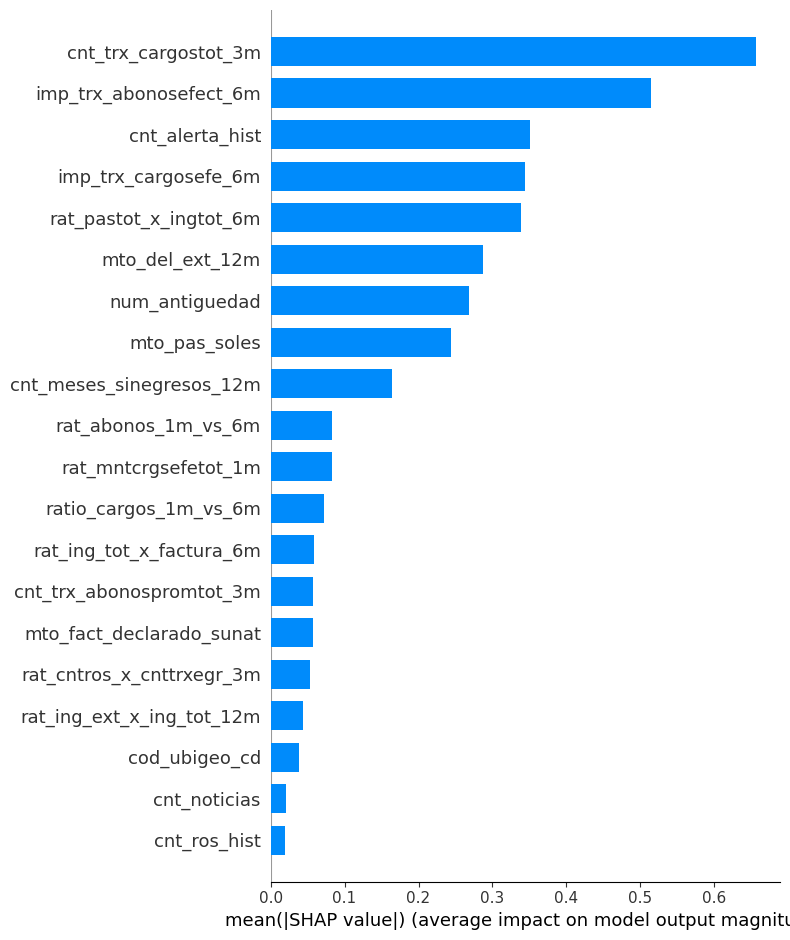

In [69]:
import shap
import pandas as pd
import numpy as np

# ===============================
# Dataset de referencia (ej: 202508)
# ===============================
df_ref = df_test[
    (df_test.cod_mes == 202508) 
    #&(df_test.tipo_alerta_n2 != '0')
].copy()

cols_excluir = ['key_value', 'cod_mes', 'cod_cli' , 'tipo_alerta_n2', 'target','trx_riesgo_cliente']
X_ref = df_ref.drop(columns=cols_excluir, errors='ignore')

# SHAP explainer (XGBoost)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_ref)

# Summary plot
shap.summary_plot(shap_values, X_ref, plot_type="bar")


In [70]:
variable_names = X_test.columns
# Calcula la magnitud promedio de los valores SHAP para cada variable
average_shap_values = np.abs(shap_values).mean(axis=0)

# Crea una lista de tuplas (variable, importancia, valor_absoluto)
variable_importance = [(variable_name, importance, abs_value) for variable_name, importance, abs_value in zip(variable_names, average_shap_values, shap_values.mean(axis=0))]

# Ordena la lista de importancia de mayor a menor
variable_importance.sort(key=lambda x: x[1], reverse=True)

# Obtén las variables más importantes junto con sus importancias y valores absolutos
variables_mas_importantes = [(variable[0], variable[1], variable[2]) for variable in variable_importance]

In [71]:
import csv

# Nombre del archivo CSV de salida
output_csv = 'importancia_variables.csv'

# Escribe los datos en el archivo CSV
with open(output_csv, 'w', newline='') as csvfile:
    
    # Define el escritor CSV
    csv_writer = csv.writer(csvfile)
    
    # Escribe el encabezado
    csv_writer.writerow(['Variable', 'Importancia', 'Valor Absoluto SHAP'])
    
    # Escribe los datos de cada variable
    for variable in variables_mas_importantes:
        csv_writer.writerow([variable[0], variable[1], variable[2]])


In [72]:
variables_mas_importantes

[('cnt_trx_cargostot_3m', np.float32(0.65594006), np.float32(-0.5143229)),
 ('imp_trx_abonosefect_6m', np.float32(0.5141099), np.float32(-0.44822067)),
 ('cnt_alerta_hist', np.float32(0.3508522), np.float32(-0.24057193)),
 ('imp_trx_cargosefe_6m', np.float32(0.34441102), np.float32(-0.26873758)),
 ('rat_pastot_x_ingtot_6m', np.float32(0.33827603), np.float32(-0.12897211)),
 ('mto_del_ext_12m', np.float32(0.28761014), np.float32(-0.271561)),
 ('num_antiguedad', np.float32(0.26801032), np.float32(-0.13285369)),
 ('mto_pas_soles', np.float32(0.24349764), np.float32(-0.13375555)),
 ('cnt_meses_sinegresos_12m', np.float32(0.1647252), np.float32(-0.0759421)),
 ('rat_abonos_1m_vs_6m', np.float32(0.08368758), np.float32(-0.015891802)),
 ('rat_mntcrgsefetot_1m', np.float32(0.08264553), np.float32(-0.0038303363)),
 ('ratio_cargos_1m_vs_6m', np.float32(0.07236077), np.float32(-0.050804023)),
 ('rat_ing_tot_x_factura_6m',
  np.float32(0.058947295),
  np.float32(-0.024324892)),
 ('cnt_trx_abonospro